# MiniROCKET + metadata concat → LightGBM
baseline fit on train, choose best threshold on val (balanced accuracy), evaluate on test,
per-baby F1, classification report, confusion matrix, and SHAP explainability.

In [3]:
# %%
# Imports and configuration
import os
import sys
import numpy as np
import pandas as pd
import warnings
from pathlib import Path
from sklearn.metrics import (balanced_accuracy_score, f1_score, classification_report,
                             confusion_matrix, matthews_corrcoef)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

# Function to find project root
# exit if not found
def find_project_root(name='Bambino', start=None):
    if start is None:
        start = os.getcwd()
    parent_dir = start
    while True:
        if os.path.basename(parent_dir) == name:
            return parent_dir
        new_parent = os.path.dirname(parent_dir)
        if new_parent == parent_dir:
            return None
        parent_dir = new_parent

PROJECT_ROOT = find_project_root('Bambino')
print('Detected project root:', PROJECT_ROOT)
try:
    sys.path.append(PROJECT_ROOT)
    print("Added project root to sys.path.")
except Exception as e:
    print("Failed to add project root to sys.path:", e)
    sys.exit(1)

from config import settings
import config_mr as conf
from DataUtils.BoaOpenFaceDataset import BoaOpenFaceDataset
from _utils_ import dataset_utils
print("Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).")
USE_PROJECT_UTILS = True

# Paths: if utils is available, use its helper; otherwise set manual paths
if USE_PROJECT_UTILS:
    TRAIN_PATH = settings.get_dataset_path(conf.dataset_type, settings.train_filename)
    VAL_PATH = settings.get_dataset_path(conf.dataset_type, settings.validation_filename)
    TEST_PATH = settings.get_dataset_path(conf.dataset_type, settings.test_filename)
else:
    TRAIN_PATH = ""
    VAL_PATH = ""
    TEST_PATH = ""

OUT_DIR = Path("./results_minirocket_lightgbm")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# MiniRocket & LightGBM
try:
    from sktime.transformations.panel.rocket import MiniRocket
except Exception as e:
    raise ImportError('MiniRocket not available: install sktime>=0.15 and dependencies')

try:
    from lightgbm import LGBMClassifier
except Exception:
    raise ImportError('lightgbm not available: pip install lightgbm')

# SHAP
try:
    import shap
except Exception:
    shap = None


Detected project root: /home/phd2/Scrivania/CorsoRepo/Bambino
Added project root to sys.path.
Loaded project config and BoaOpenFaceDataset from repo (using utils.get_dataset_path).


In [4]:
# Helper: convert BoaOpenFaceDataset -> X array [N, C, L] and y array [N]

def ds_to_numpy(ds, modalities=None):
    modality_map = {
        'g': 'gaze_info',
        'h': 'head_info',
        'f': 'face_info'
    }
    if modalities is None:
        modalities = ds.modalities if hasattr(ds, 'modalities') else ['g','h','f']
    X_list, y_list = [], []
    for inst in ds.instances:
        mats = []
        for m in modalities:
            attr = modality_map.get(m)
            if attr is None:
                raise ValueError(f"Modalità '{m}' non riconosciuta")
            mat = getattr(inst, attr)
            mats.append(np.asarray(mat))
        # concatenate on last axis time-wise (T, D) -> we need shape (C, L)
        X = np.concatenate(mats, axis=1)  # [L, D_tot]
        X_list.append(X.T)  # [D_tot, L]
        y_list.append(int(inst.trial_type))
    X_arr = np.stack(X_list, axis=0)  # [N, C, L]
    y_arr = np.array(y_list)
    return X_arr, y_arr

In [5]:
# Load datasets (reuse same dataset pickles as baseline)
print('Loading datasets for MiniRocket+LightGBM...')
train_ds = BoaOpenFaceDataset.load_dataset(TRAIN_PATH)
val_ds = BoaOpenFaceDataset.load_dataset(VAL_PATH)
test_ds = BoaOpenFaceDataset.load_dataset(TEST_PATH)

# Compute normalization on train (if you normally do) — here we'll leave temporal series raw for MiniRocket
# but we will normalize metadata using the same pipeline as baseline.

# Build metadata DataFrames
df_train = dataset_utils.dataset_to_metadata_df(train_ds)
df_val = dataset_utils.dataset_to_metadata_df(val_ds)
df_test = dataset_utils.dataset_to_metadata_df(test_ds)

# Drop any rows without labels
for df in (df_train, df_val, df_test):
    df.dropna(subset=['label'], inplace=True)

numeric_features = ["age", "duration_s"]
cat_features = ["sex"]

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])
cat_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False))])
preprocessor = ColumnTransformer(transformers=[('num', numeric_transformer, numeric_features), ('cat', cat_transformer, cat_features)])

# Fit preprocessor on train metadata
preprocessor.fit(df_train[numeric_features + cat_features])
X_meta_train = preprocessor.transform(df_train[numeric_features + cat_features])
X_meta_val = preprocessor.transform(df_val[numeric_features + cat_features])
X_meta_test = preprocessor.transform(df_test[numeric_features + cat_features])


Loading datasets for MiniRocket+LightGBM...


In [6]:
# Compute MiniRocket features
selected_modalities = train_ds.modalities if hasattr(train_ds, 'modalities') else ['g','h','f']
X_train_ts, y_train = ds_to_numpy(train_ds, modalities=selected_modalities)
X_val_ts, y_val = ds_to_numpy(val_ds, modalities=selected_modalities)
X_test_ts, y_test = ds_to_numpy(test_ds, modalities=selected_modalities)

print('Shapes:')
print('X_train_ts', X_train_ts.shape)
print('X_meta_train', X_meta_train.shape)

mr = MiniRocket()  # uses sensible defaults
X_train_feat = mr.fit_transform(X_train_ts)
X_val_feat = mr.transform(X_val_ts)
X_test_feat = mr.transform(X_test_ts)

print('MiniRocket feature shapes:', X_train_feat.shape, X_val_feat.shape, X_test_feat.shape)


Shapes:
X_train_ts (619, 38, 250)
X_meta_train (619, 4)
MiniRocket feature shapes: (619, 379848) (140, 379848) (137, 379848)


In [7]:
# Concatenate metadata features and MiniRocket features
X_train_all = np.hstack([X_train_feat, X_meta_train])
X_val_all = np.hstack([X_val_feat, X_meta_val])
X_test_all = np.hstack([X_test_feat, X_meta_test])

# Build LightGBM classifier
clf = LGBMClassifier(random_state=0, n_jobs=-1, class_weight='balanced', n_estimators=500)
clf.fit(X_train_all, y_train)

# Find best threshold on validation set
probs_val = clf.predict_proba(X_val_all)[:, 1]
best_thr = 0.5
best_bal = 0.0
for thr in np.linspace(0, 1, 101):
    preds = (probs_val >= thr).astype(int)
    bal = balanced_accuracy_score(y_val, preds)
    if bal > best_bal:
        best_bal = bal
        best_thr = thr
print(f'Best threshold on VAL: {best_thr:.2f} (bal_acc={best_bal:.4f})')


[LightGBM] [Info] Number of positive: 497, number of negative: 122
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 10.199299 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 30094632
[LightGBM] [Info] Number of data points in the train set: 619, number of used features: 378558
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=-0.000000
[LightGBM] [Info] Start training from score -0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive 


TEST set classification report:
              precision    recall  f1-score   support

           0     0.3200    0.2963    0.3077        27
           1     0.8304    0.8455    0.8378       110

    accuracy                         0.7372       137
   macro avg     0.5752    0.5709    0.5728       137
weighted avg     0.7298    0.7372    0.7334       137

TEST set confusion matrix:
[[ 8 19]
 [17 93]]
TEST balanced accuracy (thr=0.97): 0.5709
TEST Matthews correlation coefficient (thr=0.97): 0.1460

Per-baby F1 (test) — showing all babies with >=2 samples:
      pt_id  n_samples        f1
4  bam1_024         19  0.758621
2  bam1_018         20  0.787879
0  bam1_005         20  0.800000
6  bam1_044         20  0.838710
5  bam1_026         20  0.857143
1  bam1_008         18  0.903226
3  bam1_020         20  0.909091


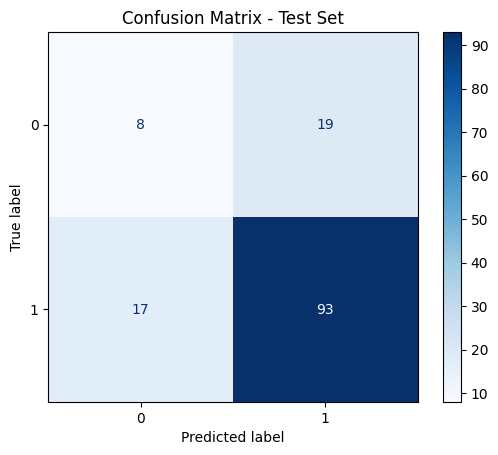

In [13]:
# Evaluate on TEST set
probs_test = clf.predict_proba(X_test_all)[:, 1]
y_pred_test = (probs_test >= best_thr).astype(int)

bal_test = balanced_accuracy_score(y_test, y_pred_test)
mcc_test = matthews_corrcoef(y_test, y_pred_test)
cm = confusion_matrix(y_test, y_pred_test)
print("\nTEST set classification report:")
print(classification_report(y_test, y_pred_test, digits=4))
print("TEST set confusion matrix:")
print(cm)
print(f"TEST balanced accuracy (thr={best_thr:.2f}): {bal_test:.4f}")
print(f"TEST Matthews correlation coefficient (thr={best_thr:.2f}): {mcc_test:.4f}\n")

# Build a map from (pt_id, trial_id) to index in test_ds.instances
map_key_to_idx = {
    (str(inst.pt_id), int(inst.trial_id)): i
    for i, inst in enumerate(test_ds.instances)
}

# Ensure X_test_feat is a NumPy array (cover DataFrame / sparse / array cases)
if hasattr(X_test_feat, "toarray"):  # e.g. sparse matrix
    X_test_feat_arr = X_test_feat.toarray()
elif isinstance(X_test_feat, np.ndarray):
    X_test_feat_arr = X_test_feat
else:
    # covers pandas DataFrame or other array-likes
    try:
        X_test_feat_arr = np.asarray(X_test_feat)
    except Exception:
        # fallback: convert via values if pandas
        X_test_feat_arr = X_test_feat.values

# Now compute per-baby F1 using the correct row selection
pt_ids = df_test["pt_id"].unique()
per_baby = []
for pid in pt_ids:
    sub = df_test[df_test["pt_id"] == pid]
    if len(sub) < 2:
        continue

    # Build list of indices into test_ds.instances for this baby's trials
    idxs = []
    for _, row in sub.iterrows():
        key = (str(row["pt_id"]), int(row["trial_id"]))
        if key in map_key_to_idx:
            idxs.append(map_key_to_idx[key])
        else:
            # optionally print or log missing mapping (helps debug mismatches)
            # print(f"Warning: no temporal index for {key}")
            pass

    if not idxs:
        # no temporal features found for this baby -> skip
        continue

    # Select the temporal features rows for this baby (integer row selection)
    X_sub_ts_feat = X_test_feat_arr[idxs]   # now works because this is a NumPy array

    # Metadata for this baby (order corresponds to 'sub' rows)
    X_sub_meta = preprocessor.transform(sub[numeric_features + cat_features])

    # If X_sub_meta has shape [n_samples, meta_dim] and there are n_samples rows,
    # ensure alignment: the number of temporal rows (len(idxs)) should match len(sub).
    # If not, you'll need to align carefully (e.g. by matching (pt_id, trial_id) order).
    if X_sub_ts_feat.shape[0] != X_sub_meta.shape[0]:
        # If shapes differ, try to reorder X_sub_meta to match idxs order
        # Build list of keys in the same order as idxs, then reindex 'sub' accordingly
        ordered_keys = [(test_ds.instances[i].pt_id, test_ds.instances[i].trial_id) for i in idxs]
        # convert keys to same types used in df (str,int)
        ordered_keys = [(str(k[0]), int(k[1])) for k in ordered_keys]
        # build mapping from key to row in 'sub'
        sub_key_to_row = {(str(r.pt_id), int(r.trial_id)): r for _, r in sub.iterrows()}
        reordered_rows = []
        for k in ordered_keys:
            if k in sub_key_to_row:
                reordered_rows.append(sub_key_to_row[k])
        if len(reordered_rows) == len(idxs):
            sub_reordered = pd.DataFrame(reordered_rows)
            X_sub_meta = preprocessor.transform(sub_reordered[numeric_features + cat_features])
        else:
            # if reordering fails, skip this baby to avoid misaligned concatenation
            print(f"Warning: couldn't align metadata and temporal features for baby {pid}; skipping.")
            continue

    X_sub_all = np.hstack([X_sub_ts_feat, X_sub_meta])
    f1 = f1_score(sub["label"].astype(int), (clf.predict_proba(X_sub_all)[:, 1] >= best_thr).astype(int))
    per_baby.append((pid, len(sub), f1))

per_baby_df = pd.DataFrame(per_baby, columns=["pt_id", "n_samples", "f1"]).sort_values("f1")
print("Per-baby F1 (test) — showing all babies with >=2 samples:")
print(per_baby_df)

# confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

disp = ConfusionMatrixDisplay(confusion_matrix=confusion_matrix(y_test, y_pred_test),
                               display_labels=clf.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix - Test Set")
plt.savefig(OUT_DIR / "minirocket_confusion_matrix_test.png")
plt.show()


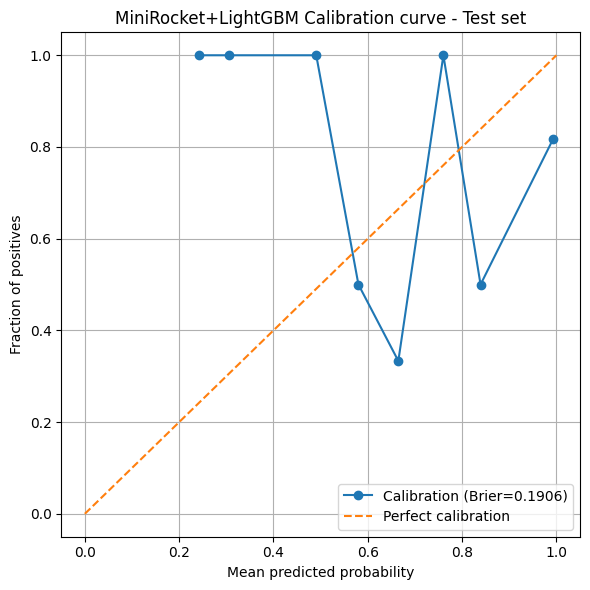

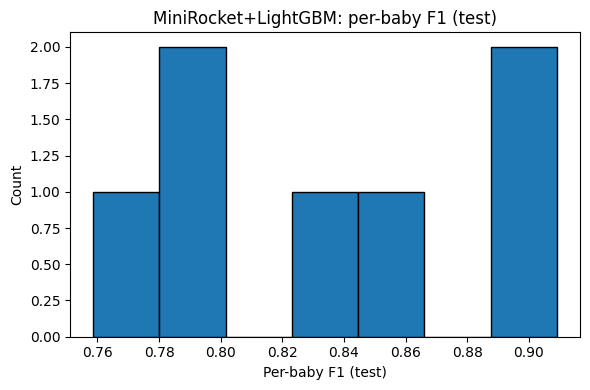

In [18]:
# Calibration + per-baby histogram for MiniRocket model
from sklearn.calibration import calibration_curve
from sklearn.metrics import brier_score_loss

fraction_of_positives, mean_predicted_value = calibration_curve(y_test, probs_test, n_bins=10)
brier = brier_score_loss(y_test, probs_test)
plt.figure(figsize=(6,6))
plt.plot(mean_predicted_value, fraction_of_positives, marker='o', label=f'Calibration (Brier={brier:.4f})')
plt.plot([0,1], [0,1], linestyle='--', label='Perfect calibration')
plt.xlabel('Mean predicted probability')
plt.ylabel('Fraction of positives')
plt.title('MiniRocket+LightGBM Calibration curve - Test set')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig(OUT_DIR / 'minirocket_calibration_curve_test.png', dpi=200)
plt.show()

if not per_baby_df.empty:
    plt.figure(figsize=(6,4))
    plt.hist(per_baby_df['f1'].dropna(), bins=min(20, len(per_baby_df)), edgecolor='black')
    plt.xlabel('Per-baby F1 (test)')
    plt.ylabel('Count')
    plt.title('MiniRocket+LightGBM: per-baby F1 (test)')
    plt.tight_layout()
    plt.savefig(OUT_DIR / 'minirocket_per_baby_f1_hist.png', dpi=200)
    plt.show()


Computing SHAP values for MiniRocket+LightGBM...


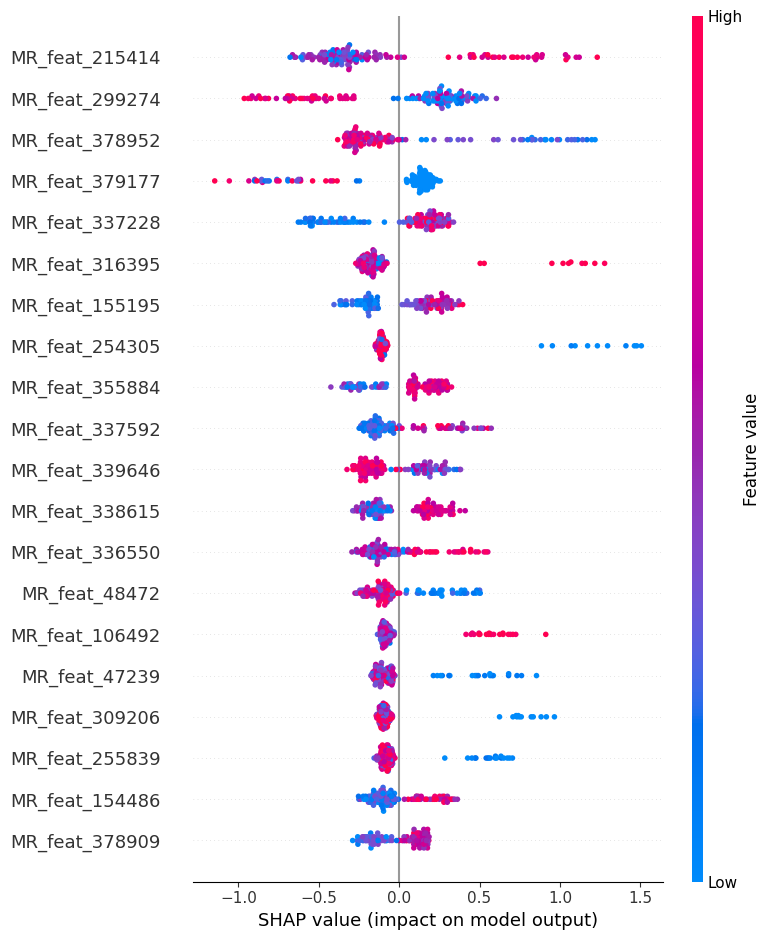

In [21]:
# --- SHAP ---
import shap

if shap is not None:
    try:
        # 1) MR feature names
        mr_feature_names = [f'MR_feat_{i}' for i in range(X_train_feat.shape[1])]
        # 2) Metadata feature names from preprocessor
        meta_feature_names = []
        # numeric features
        meta_feature_names.extend(numeric_features)
        # categorical features (get names from OneHotEncoder)
        ohe = preprocessor.named_transformers_['cat'].named_steps['onehot']
        cat_ohe_names = ohe.get_feature_names_out(cat_features)
        meta_feature_names.extend(cat_ohe_names)
        # Combine all feature names
        all_feature_names = mr_feature_names + meta_feature_names

        # Build DataFrame for test set with proper column names
        X_test_all_df = pd.DataFrame(X_test_all, columns=all_feature_names)

        # SHAP explanation using TreeExplainer
        print("Computing SHAP values for MiniRocket+LightGBM...")
        explainer = shap.TreeExplainer(clf)
        shap_vals = explainer(X_test_all_df)  # returns a ShapValues object
        # SHAP summary plot using DataFrame and save it
        shap.summary_plot(shap_vals, X_test_all_df, show=False)
        plt.gcf().savefig(OUT_DIR / "minirocket_shap_summary_named.png", dpi=200, bbox_inches='tight')
    except Exception as e:
        print("SHAP explanation failed:", e)
else:
    print("SHAP not available; skipping SHAP explanations.")